In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [2]:
import argparse

parser = argparse.ArgumentParser(description="CIFAR Influence Experiment with Partial Retraining")

# Random seed
parser.add_argument('--random_seed', type=int, default=42, help='Random seed for training')
parser.add_argument('--probe_seed', type=int, default=105, help='Random seed for probe selection (if None, uses random_seed)')

# Model parameters
parser.add_argument('--batch_size', type=int, default=16, help='Batch size for training')
parser.add_argument('--learning_rate', type=float, default=0.01, help='Learning rate')
parser.add_argument('--epochs', type=int, default=10, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-8, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=100, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=1, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.001, help='Step size')
parser.add_argument('--n_steps', type=int, default=50, help='PGD iterations')

args, _ = parser.parse_known_args()

# Set probe_seed to random_seed if not specified
if args.probe_seed is None:
    args.probe_seed = args.random_seed
    
print(f"Training seed: {args.random_seed}")
print(f"Probe selection seed: {args.probe_seed}")

Training seed: 42
Probe selection seed: 105


In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

# Set random seed for deterministic model initialization
torch.manual_seed(args.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

# Enable deterministic mode for CUDA operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to: {args.random_seed}")
print(f"CUDA deterministic mode: enabled")
print(f"Dataloader shuffle: False\n")

Device: cuda
PyTorch version: 2.7.0+cu128
Random seed set to: 42
CUDA deterministic mode: enabled
Dataloader shuffle: False



In [4]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_ds = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_ds = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Create a validation split from the training set (e.g., 90% train, 10% val)
num_train = int(0.9 * len(full_train_ds))
num_valid = len(full_train_ds) - num_train
train_ds, valid_ds = random_split(full_train_ds, [num_train, num_valid], generator=torch.Generator().manual_seed(args.random_seed))

img, label = full_train_ds[2]
print(img.shape)  # torch.Size([3, 32, 32])

from infusion.dataloader import get_dataloader

# Dataloaders (use seed for deterministic data ordering)
train_dl = get_dataloader(train_ds, args.batch_size, seed=args.random_seed)
test_dl = get_dataloader(test_ds, args.batch_size, seed=args.random_seed)
valid_dl = get_dataloader(valid_ds, args.batch_size, seed=args.random_seed)

torch.Size([3, 32, 32])


In [5]:
import os
from infusion.train import fit

# Grab dataset metadata for CIFAR10
in_channels = full_train_ds[0][0].shape[0]    # 3
img_size = full_train_ds[0][0].shape[1]       # 32 for CIFAR10
num_classes = len(full_train_ds.classes)       # 10

import torch
import torch.nn as nn

# A tiny ResNet-like network with a couple of residual blocks for CIFAR/MNIST
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class TinyResNet(nn.Module):
    def __init__(self, input_channels, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)

        # First residual block
        self.layer1 = ResidualBlock(32, 32)
        # Down + increase channels
        self.layer2 = ResidualBlock(32, 64, stride=2, downsample=nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(64)
        ))
        # Another downsampling block
        self.layer3 = ResidualBlock(64, 128, stride=2, downsample=nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(128)
        ))

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# For CIFAR10, input_dim is 3*32*32 = 3072
input_dim = in_channels * img_size * img_size

def make_model():
    return TinyResNet(input_channels=in_channels, num_classes=num_classes).to(device)

model = make_model()
num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")

# Use SGD optimizer
opt = torch.optim.SGD(model.parameters(), lr=args.learning_rate)
loss_func = torch.nn.CrossEntropyLoss()

ckpt_dir = "./checkpoints/cifar/pretrain/"
ckpt_path = ckpt_dir + f"ckpt_epoch_{args.epochs}.pth"

print(f"Training model for {args.epochs} epochs...")
if os.path.exists(ckpt_path):
    print(f"Checkpoint found at {ckpt_path}. Loading model...")
    checkpoint = torch.load(ckpt_path, map_location=device)
    
    # Handle both old format (state_dict only) and new format (dict with metadata)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        # New format with metadata
        model.load_state_dict(checkpoint['model_state_dict'])
        training_seed = checkpoint.get('random_seed', 'unknown')
        print(f"  Model was trained with seed: {training_seed}")
        print(f"  Current probe selection will use seed: {args.probe_seed}")
    else:
        # Old format (just state_dict)
        model.load_state_dict(checkpoint)
        print(f"  Loaded old format checkpoint (no metadata)")
        print(f"  Current probe selection will use seed: {args.probe_seed}")
else:
    print("Checkpoint not found. Training model from scratch...")
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir, exist_ok=True)
    fit(args.epochs, model, loss_func, opt, train_dl, valid_dl, ckpt_dir, random_seed=args.random_seed)

Number of parameters in the model: 308650
Training model for 10 epochs...
Checkpoint found at ./checkpoints/cifar/pretrain/ckpt_epoch_10.pth. Loading model...
  Model was trained with seed: 42
  Current probe selection will use seed: 105


In [6]:
# Calculate model accuracy on the test set
correct = 0
total = 0
with torch.no_grad():
    for x, y in tqdm(test_dl):
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        predicted = outputs.argmax(dim=-1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy after {args.epochs} epochs: {accuracy * 100:.2f}%")

  0%|          | 0/625 [00:00<?, ?it/s]

100%|██████████| 625/625 [00:01<00:00, 451.30it/s]

Test accuracy after 10 epochs: 73.00%


### Influence Functions

In [7]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


### Define Probe Point

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

Probe selection using seed: 105
Test point index: 4308
True label (= Predicted): 0 (airplane)
Target class: 6 (frog)
Probability of true class: 0.674
Probability of target class: 0.038


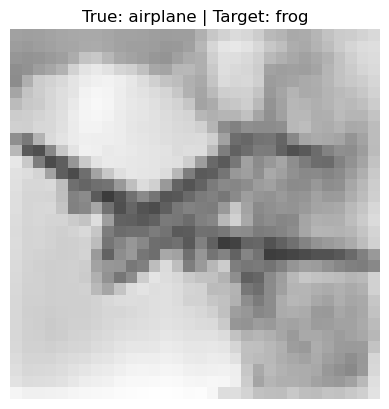

In [8]:
# Find a test point where model's prediction matches the true label
import random

# Use probe_seed for probe selection (allows different probe points with same trained model)
random.seed(args.probe_seed)
torch.manual_seed(args.probe_seed)

# Set model to eval mode for consistent predictions
model.eval()

found = False
shuffled_indices = list(range(len(test_ds)))
random.shuffle(shuffled_indices)
for idx in shuffled_indices:
    x_star, y_label = test_ds[idx]
    
    # Get model's prediction
    with torch.no_grad():
        logits = model(x_star.unsqueeze(0).to(device))
        y_pred = torch.argmax(logits).item()
    
    # Check if prediction matches true label
    if y_pred == y_label:
        found = True
        break

if not found:
    raise RuntimeError("No test point found where prediction matches true label")

# Select a random target class (different from the true/predicted label)
num_classes = len(test_ds.classes)
available_classes = [c for c in range(num_classes) if c != y_label]
y_star = random.choice(available_classes)

# Get probabilities for display
with torch.no_grad():
    probs = F.softmax(logits, dim=1)[0]
    prob_true = probs[y_label].item()
    prob_target = probs[y_star].item()

print(f"Probe selection using seed: {args.probe_seed}")
print(f"Test point index: {idx}")
print(f"True label (= Predicted): {y_label} ({test_ds.classes[y_label]})")
print(f"Target class: {y_star} ({test_ds.classes[y_star]})")
print(f"Probability of true class: {prob_true:.3f}")
print(f"Probability of target class: {prob_target:.3f}")

# Display the image
plt.imshow(x_star.permute(1, 2, 0))
plt.title(f"True: {test_ds.classes[y_label]} | Target: {test_ds.classes[y_star]}")
plt.axis('off')
plt.show()

In [9]:
# Create a single-example dataset containing only the probe point
from torch.utils.data import Dataset

class ProbeDataset(Dataset):
    """Simple dataset containing a single probe point (x_star, y_star)"""
    def __init__(self, x_star, y_star):
        self.x_star = x_star
        self.y_star = y_star
    
    def __len__(self):
        return 1
    
    def __getitem__(self, idx):
        return self.x_star, self.y_star

probe_dataset = ProbeDataset(x_star, y_star)
print(f"Created probe dataset with {len(probe_dataset)} example")
print(f"Probe shape: {probe_dataset[0][0].shape}, Target class: {probe_dataset[0][1]}")

Created probe dataset with 1 example
Probe shape: torch.Size([3, 32, 32]), Target class: 6


In [10]:
class ClassificationTask(Task):

    def __init__(self):
        super().__init__()

    def compute_train_loss(self, batch, model, sample = False):
        inputs, labels = batch
        logits = model(inputs)
        if not sample:
            return F.cross_entropy(logits, labels, reduction="sum")
        with torch.no_grad():
            probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
            sampled_labels = torch.multinomial(
                probs,
                num_samples=1,
            ).flatten()
        return F.cross_entropy(logits, sampled_labels, reduction="sum")

    
    def compute_measurement(
        self,
        batch,
        model: nn.Module,
    ) -> torch.Tensor:
        inputs, targets = batch

        # Ensure inputs are on the correct device
        if isinstance(inputs, torch.Tensor):
            inputs = inputs.to(model.device if hasattr(model, 'device') else next(model.parameters()).device)
        if isinstance(targets, torch.Tensor):
            targets = targets.to(model.device if hasattr(model, 'device') else next(model.parameters()).device)

        # Compute logits and log probabilities
        logits = model(inputs)  # [batch_size, num_classes]
        log_probs = F.log_softmax(logits, dim=-1)  # [batch_size, num_classes]

        # Extract log probability for the target class for each example
        bindex = torch.arange(logits.shape[0]).to(logits.device, non_blocking=False)
        log_probs_target = log_probs[bindex, targets]

        # Return the sum of log probabilities for the batch
        return log_probs_target.sum()

In [11]:
model = model.eval()
task = ClassificationTask()
model = prepare_model(model, task)

# Set up the Analyzer class
analyzer = Analyzer(
    analysis_name="cifar",
    model=model,
    task=task,
)
dataloader_kwargs = DataLoaderKwargs(num_workers=4)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

# Fit all factors
analyzer.fit_all_factors(
    factors_name="ekfac",
    dataset=train_ds,
    per_device_batch_size=2048,
    overwrite_output_dir=True,
)

# Use the non-augmented version of the training dataset for influence score computations
eval_train_dataset = train_ds

# Create ScoreArguments with custom damping factor from args
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

# Compute pairwise influence scores
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=probe_dataset,
    train_dataset=eval_train_dataset,
    per_device_query_batch_size=1,
    score_args=score_args,
    overwrite_output_dir=True,
)

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [0/22]   0%|           [time left: ?, time spent: 00:00]

Fitting covariance matrices [22/22] 100%|██████████ [time left: 00:00, time spent: 00:03]
Performing Eigendecomposition [10/10] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [22/22] 100%|██████████ [time left: 00:00, time spent: 00:03]


Using damping factor: 1e-08


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [11/11] 100%|██████████ [time left: 00:00, time spent: 00:03]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:03]


In [12]:
scores = analyzer.load_pairwise_scores("ekfac_scores")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: (1, {len(train_ds)}) - one query point, all training examples")

# Extract the single row of scores for the probe point
probe_scores = scores[0]  # Shape: (N_train,)
print(f"Probe scores shape: {probe_scores.shape}")

Scores shape: torch.Size([1, 45000])
Expected shape: (1, 45000) - one query point, all training examples
Probe scores shape: torch.Size([45000])


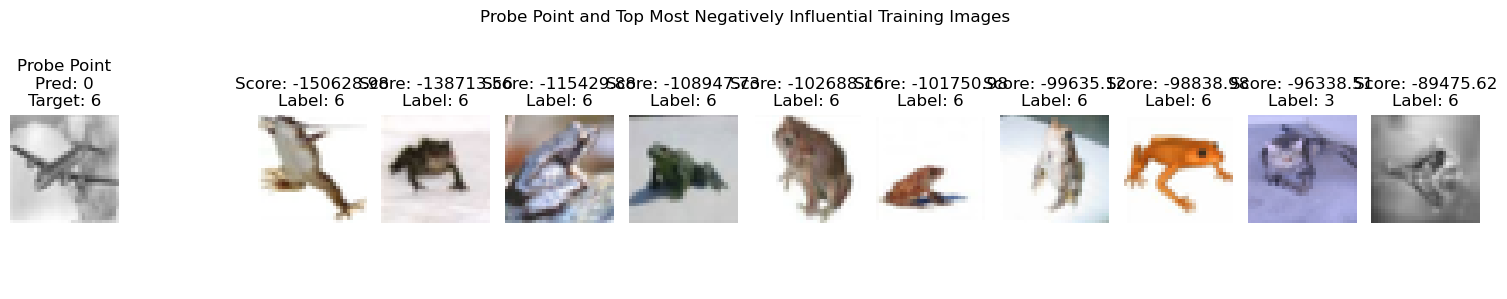


Influence Score Statistics:
  Min: -150628.9844
  Max: 165263.4531
  Mean: 28.5428
  Std: 9497.2129

Top 5 Most Negatively Influential Training Examples:
  1. Index 5184: Label 6, Score -150628.9844
  2. Index 5192: Label 6, Score -138713.5625
  3. Index 17967: Label 6, Score -115429.8750
  4. Index 17114: Label 6, Score -108947.7266
  5. Index 36635: Label 6, Score -102688.1641


In [13]:
import numpy as np

def to_display_img(img):
    """
    Converts a tensor or numpy array image of shape (C, H, W) 
    to a valid image shape for matplotlib imshow.
    """
    if isinstance(img, np.ndarray):
        arr = img
    else:
        arr = img.numpy()
    if arr.ndim == 3 and arr.shape[0] in [1, 3]:
        # (C, H, W) -> (H, W, C)
        arr = np.transpose(arr, (1, 2, 0))
        if arr.shape[2] == 1:
            arr = arr[:, :, 0]  # For single channel images, drop the last dimension
    elif arr.ndim == 2:
        pass  # Already (H, W)
    return arr

# Switch for influence score selection
# Options: "neg" (most negative), "pos" (most positive), "abs" (most absolute)
influence_mode = "neg"

if influence_mode == "neg":
    # Most negative influence
    top_k_indices = probe_scores.argsort(descending=False)[:args.top_k]
    mode_desc = "Most Negatively Influential"
elif influence_mode == "pos":
    # Most positive influence
    top_k_indices = probe_scores.argsort(descending=True)[:args.top_k]
    mode_desc = "Most Positively Influential"
elif influence_mode == "abs":
    # Highest-magnitude (absolute value) influence, regardless of sign
    top_k_indices = probe_scores.abs().argsort(descending=True)[:args.top_k]
    mode_desc = "Most Absolutely Influential"
else:
    raise ValueError(f"Invalid influence_mode: {influence_mode}")

# Visualization
n_examp = 10
fig, axs = plt.subplots(ncols=2+n_examp, figsize=(15, 3))
fig.suptitle(f"Probe Point and Top {mode_desc} Training Images")

# Show probe point
axs[0].imshow(to_display_img(x_star))
axs[0].axis("off")
axs[0].set_title(f"Probe Point\nPred: {y_pred}\nTarget: {y_star}")
axs[1].axis("off")

# Show most influential training examples according to mode
for ii, idx in enumerate(top_k_indices[:n_examp]):
    train_img, train_label = train_ds[idx]
    axs[ii + 2].imshow(to_display_img(train_img))
    axs[ii + 2].axis("off")
    axs[ii + 2].set_title(f"Score: {probe_scores[idx]:.2f}\nLabel: {train_label}")

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.4f}")
print(f"  Max: {probe_scores.max():.4f}")
print(f"  Mean: {probe_scores.mean():.4f}")
print(f"  Std: {probe_scores.std():.4f}")

print(f"\nTop 5 {mode_desc} Training Examples:")
for i, idx in enumerate(top_k_indices[:5]):
    train_img, train_label = train_ds[idx]
    print(f"  {i+1}. Index {idx}: Label {train_label}, Score {probe_scores[idx]:.4f}")

## 7. Compute Optimal Perturbations via PGD

Apply projected gradient descent in input space:

$$z_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(z_t + \alpha \cdot \text{sign}(G_\delta(z_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$

In [14]:
[p for p in model.parameters() if p.requires_grad]

[Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True)]

In [15]:
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

def get_tracked_params_and_ihvp(model, enable_grad=True):
    """
    Returns:
        params: list of original_module parameters for all tracked modules in model (ordered)
        v_list: list of IHVPs corresponding to each tracked module (one IHVP per module, not per parameter)
    """
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {tracked_module_names}")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            print(f"Module {name} has parameters:")
            ihvp = module.storage["inverse_hessian_vector_product"]

            # Collect all parameters for this module
            for param_name, param in module.original_module.named_parameters():
                print(f"  - {param_name}: {param.shape}")
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            # Add IHVP only once per module (not per parameter)
            v_list.append(ihvp)

    return params, v_list
    

params, v_list = get_tracked_params_and_ihvp(model, enable_grad=True)
print(f"\nNumber of tracked modules: {len(v_list)}")
print(f"Number of parameters: {len(params)}")
for i, v in enumerate(v_list):
    print(f"IHVP {i} shape: {v.shape}")

# Make sure IHVPs are on the same device and don't require grad
device_v = next(model.parameters()).device
v_list = [v.to(device_v).detach() for v in v_list]

with torch.no_grad():
    total_sq = sum((v**2).sum() for v in v_list)
    norm = torch.sqrt(total_sq) + 1e-12
v_list_norm = [v / norm for v in v_list]

Tracked modules: ['conv', 'layer1.conv1', 'layer1.conv2', 'layer2.conv1', 'layer2.conv2', 'layer2.downsample.0', 'layer3.conv1', 'layer3.conv2', 'layer3.downsample.0', 'fc']
Module conv has parameters:
  - weight: torch.Size([32, 3, 3, 3])
Module layer1.conv1 has parameters:
  - weight: torch.Size([32, 32, 3, 3])
Module layer1.conv2 has parameters:
  - weight: torch.Size([32, 32, 3, 3])
Module layer2.conv1 has parameters:
  - weight: torch.Size([64, 32, 3, 3])
Module layer2.conv2 has parameters:
  - weight: torch.Size([64, 64, 3, 3])
Module layer2.downsample.0 has parameters:
  - weight: torch.Size([64, 32, 1, 1])
Module layer3.conv1 has parameters:
  - weight: torch.Size([128, 64, 3, 3])
Module layer3.conv2 has parameters:
  - weight: torch.Size([128, 128, 3, 3])
Module layer3.downsample.0 has parameters:
  - weight: torch.Size([128, 64, 1, 1])
Module fc has parameters:
  - weight: torch.Size([10, 128])
  - bias: torch.Size([10])

Number of tracked modules: 10
Number of parameters: 11

In [16]:
import torch
import torch.nn.functional as F

from common.G_delta import compute_G_delta_batched_core


def compute_G_delta_image_batched(model, X_batch, y_batch, v_list, n_train):
    """
    Image classification wrapper.
    Returns: [B, C, H, W]
    """
    def forward_and_loss_fn(model_, x_):
        logits = model_(x_)
        return F.cross_entropy(logits, y_batch, reduction="sum")

    return compute_G_delta_batched_core(
        model=model,
        input_requires_grad=X_batch,
        v_list=v_list,
        n_train=n_train,
        forward_and_loss_fn=forward_and_loss_fn,
        allow_unused=False,
        grad_dtype=None,
        nan_to_zero=False,
    )



def apply_pgd_perturbation(model, X_batch, y_batch, v_list, n_train,
                          epsilon=2.0, alpha=0.3, n_steps=20, norm='inf',
                          verbose=False, return_stats=False):
    """
    Apply PGD to find optimal perturbations that maximize observable f(θ)

    z_{t+1} = Proj(z_t + α · sign(G_δ(z_t)))

    """
    X_orig = X_batch.clone()
    X_adv = X_batch.clone()
    B = X_batch.size(0)

    def project_linf(x0, x_cand, eps):
        return torch.clamp(x_cand, x0 - eps, x0 + eps)

    def project_l2(x0, x_cand, eps):
        delta = x_cand - x0
        norms = torch.norm(delta.reshape(B, -1), p=2, dim=1, keepdim=True)
        scale = torch.clamp(eps / (norms + 1e-12), max=1.0)
        return x0 + delta * scale.reshape(-1, *([1] * (delta.ndim - 1)))

    # Always track convergence for return_stats
    grad_norms = []
    pert_norms_history = []

    # PGD iterations
    for step in range(n_steps):
        # Compute gradient direction
        G_delta = compute_G_delta_image_batched(model, X_adv, y_batch, v_list, n_train)

        # Track metrics
        gnorm = G_delta.abs().mean().item()
        grad_norms.append(gnorm)

        current_delta = X_adv - X_orig
        if norm == 'inf':
            pnorm = torch.norm(current_delta.reshape(B, -1), p=float('inf'), dim=1).mean().item()
        else:
            pnorm = torch.norm(current_delta.reshape(B, -1), p=2, dim=1).mean().item()
        pert_norms_history.append(pnorm)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            print(f"  Step {step:3d}: ||G_δ|| = {gnorm:.6f}, ||δ|| = {pnorm:.6f}")

        # Take step
        if norm == 'inf':
            step_vec = alpha * torch.sign(G_delta)
            X_cand = X_adv + step_vec
            X_adv = project_linf(X_orig, X_cand, epsilon)
        elif norm == '2':
            g_norms = torch.norm(G_delta.reshape(B, -1), p=2, dim=1, keepdim=True) + 1e-12
            step_vec = alpha * (G_delta / g_norms.reshape(-1, 1))
            X_cand = X_adv + step_vec
            X_adv = project_l2(X_orig, X_cand, epsilon)
        else:
            raise ValueError(f"Unknown norm: {norm}")

    # Compute final perturbation norms
    delta = X_adv - X_orig
    if norm == 'inf':
        pert_norms = torch.norm(delta.reshape(B, -1), p=float('inf'), dim=1)
    else:
        pert_norms = torch.norm(delta.reshape(B, -1), p=2, dim=1)

    # Print convergence analysis
    if verbose:
        print(f"\nConvergence Analysis:")
        print(f"  Initial gradient norm: {grad_norms[0]:.6f}")
        print(f"  Final gradient norm: {grad_norms[-1]:.6f}")
        print(f"  Gradient reduction: {grad_norms[-1]/grad_norms[0]:.2e}")
        print(f"  Final perturbation norm: {pert_norms_history[-1]:.6f}")
        print(f"  Epsilon budget: {epsilon:.6f}")
        if pert_norms_history[-1] < epsilon * 0.9:
            print(f"  → PGD CONVERGED before hitting epsilon constraint")
        else:
            print(f"  → Hit epsilon constraint")

    if return_stats:
        stats = {
            'initial_grad_norm': grad_norms[0],
            'final_grad_norm': grad_norms[-1],
            'gradient_reduction': grad_norms[-1] / (grad_norms[0] + 1e-12),
            'grad_history': grad_norms,
            'pert_norms_history': pert_norms_history,
            'converged': pert_norms_history[-1] < epsilon * 0.9
        }
        return X_adv, pert_norms, stats

    return X_adv, pert_norms

In [17]:
print(f"Applying PGD perturbation...")
print(f"  ε = {args.epsilon} (L_∞ budget)")
print(f"  α = {args.alpha} (step size)")
print(f"  Steps = {args.n_steps}\n")

# Get selected batch
orig_dataset = train_ds.dataset if hasattr(train_ds, 'dataset') else train_ds
orig_indices = train_ds.indices if hasattr(train_ds, 'indices') else range(len(train_ds))
selected_indices = [orig_indices[i] for i in top_k_indices]

imgs, labels = zip(*(orig_dataset[i] for i in selected_indices))
X_selected = torch.stack(imgs).to(device)
y_selected = torch.tensor(labels).to(device)
n_train = len(train_ds)

# Apply PGD with convergence monitoring
X_perturbed, pert_norms = apply_pgd_perturbation(
    model, X_selected, y_selected, v_list_norm, len(train_ds),
    epsilon=args.epsilon,
    alpha=args.alpha,
    n_steps=args.n_steps,
    norm='inf',
    verbose=True
)

print(f"\nPerturbation applied!")
print(f"  Mean L_∞ norm: {pert_norms.mean():.4f}")
print(f"  Max L_∞ norm: {pert_norms.max():.4f}")

Applying PGD perturbation...
  ε = 1 (L_∞ budget)
  α = 0.001 (step size)
  Steps = 50

  Step   0: ||G_δ|| = 0.000000, ||δ|| = 0.000000


  Step  10: ||G_δ|| = 0.000000, ||δ|| = 0.010000
  Step  20: ||G_δ|| = 0.000000, ||δ|| = 0.020000
  Step  30: ||G_δ|| = 0.000000, ||δ|| = 0.030001
  Step  40: ||G_δ|| = 0.000000, ||δ|| = 0.040001
  Step  49: ||G_δ|| = 0.000000, ||δ|| = 0.049001

Convergence Analysis:
  Initial gradient norm: 0.000000
  Final gradient norm: 0.000000
  Gradient reduction: 4.56e-01
  Final perturbation norm: 0.049001
  Epsilon budget: 1.000000
  → PGD CONVERGED before hitting epsilon constraint

Perturbation applied!
  Mean L_∞ norm: 0.0500
  Max L_∞ norm: 0.0500


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.020666713..1.0500023].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.15000701].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.032352958..1.0500023].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.15000701].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09901951..1.0144709].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.1500003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15

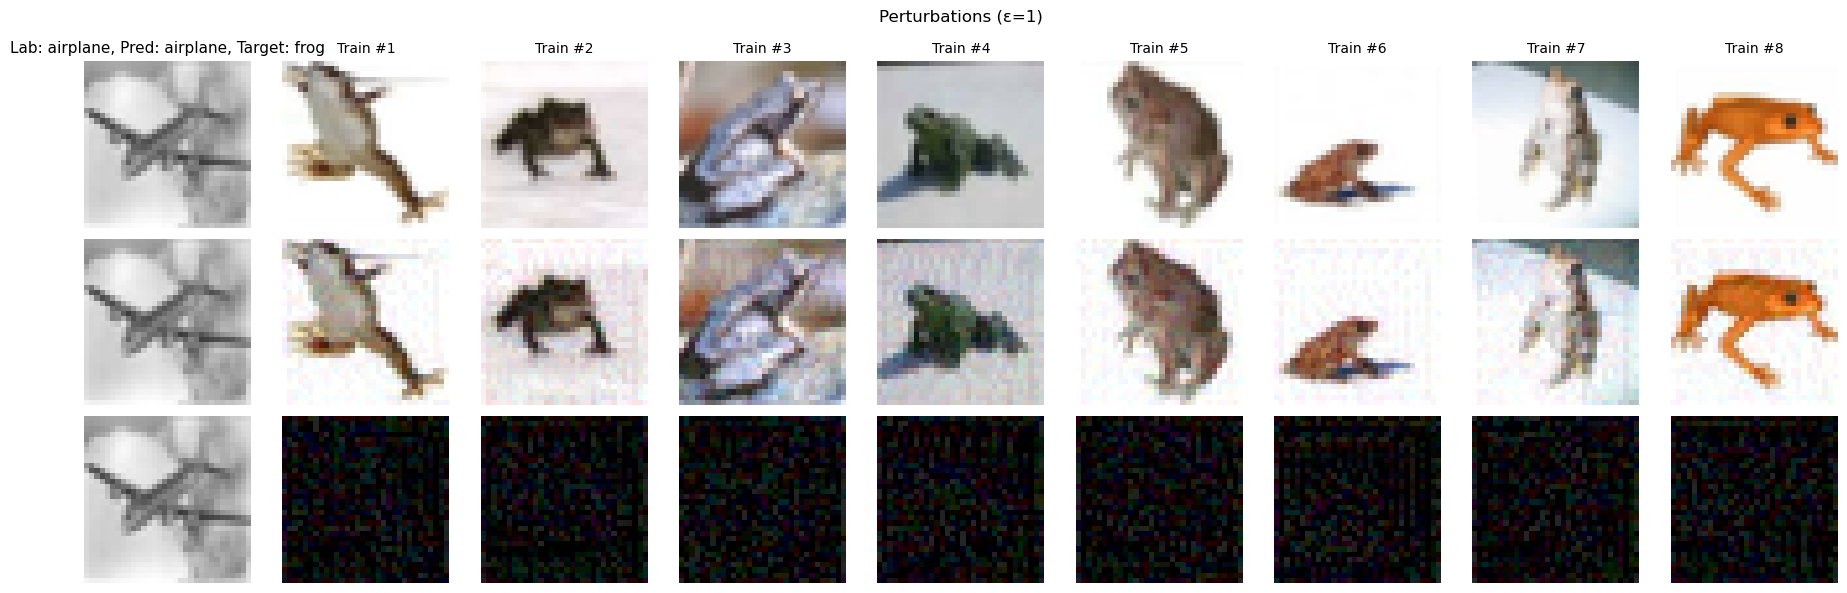

In [18]:
# Visualize perturbations
n_show = min(8, X_selected.shape[0])

fig, axes = plt.subplots(3, n_show + 1, figsize=(2*(n_show + 1), 6))

img_shape = X_selected.shape[1:]
is_grayscale = (len(img_shape) == 2) or (img_shape[0] == 1)
cmap = 'gray' if is_grayscale else None

def prep_image(x):
    x = x.detach().cpu()
    if len(x.shape) == 3 and x.shape[0] == 1:
        return x[0]
    if len(x.shape) == 3 and x.shape[0] == 3:
        return x.permute(1, 2, 0)
    if len(x.shape) == 2:
        return x
    raise ValueError(f'Unexpected image shape: {x.shape}')

# Plot the probe image on the far left (column 0)
if 'x_star' in locals():
    probe_img = prep_image(x_star)
    for row in range(3):
        axes[row, 0].imshow(probe_img, cmap=cmap)
        axes[row, 0].axis('off')
    axes[0, 0].set_ylabel('Probe', fontsize=10)
    axes[0, 0].set_title('Probe\n(Query)', fontsize=10)
else:
    for row in range(3):
        axes[row, 0].axis('off')
    axes[0, 0].set_ylabel('Probe', fontsize=10)
    axes[0, 0].set_title('Probe\n(Query)', fontsize=10)

# Plot each of the selected training images and their perturbation/difference
for i in range(n_show):
    col = i + 1

    # Original
    axes[0, col].imshow(prep_image(X_selected[i]), cmap=cmap)
    axes[0, col].axis('off')
    if col == 1:
        axes[0, col].set_ylabel('Original', fontsize=10)

    # Perturbed
    axes[1, col].imshow(prep_image(X_perturbed[i]), cmap=cmap)
    axes[1, col].axis('off')
    if col == 1:
        axes[1, col].set_ylabel('Perturbed', fontsize=10)

    # Difference (amplified for visibility)
    diff = (X_perturbed[i] - X_selected[i]).detach().cpu()
    if len(diff.shape) == 3 and diff.shape[0] == 1:
        diff_to_show = diff[0]
    elif len(diff.shape) == 3 and diff.shape[0] == 3:
        diff_to_show = diff.permute(1, 2, 0)
    else:
        diff_to_show = diff

    diff_vis = diff_to_show / args.epsilon
    diff_vis = torch.clamp(diff_vis, -1.0, 1.0)
    contrast_factor = 3.0
    diff_vis_enhanced = diff_vis * contrast_factor
    diff_vis_enhanced = torch.clamp(diff_vis_enhanced, -1.0, 1.0)
    axes[2, col].imshow(diff_vis_enhanced, cmap='bwr', vmin=-1, vmax=1)
    axes[2, col].axis('off')
    if col == 1:
        axes[2, col].set_ylabel('Δ (difference)', fontsize=10)

axes[0, 0].set_title(f"Lab: {test_ds.classes[y_label]}, Pred: {test_ds.classes[y_pred]}, Target: {test_ds.classes[y_star]}", fontsize=11)
for i in range(n_show):
    axes[0, i + 1].set_title(f"Train #{i+1}", fontsize=10)

plt.suptitle(f'Perturbations (ε={args.epsilon})', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Partial Retraining: Load from Epoch 9, Train Only Epoch 10

Following the GPT-Neo infusion pattern:
1. Load model state from epoch 9 checkpoint
2. Load optimizer state (or recreate)
3. Train for exactly 1 epoch with perturbed data
4. Save to separate checkpoint directory

In [19]:
from common.infusable_dataset import InfusableDataset

# Create InfusableDataset wrapping train_ds with "infused" return mode for training
modified_dataset = InfusableDataset(train_ds, return_mode="infused")

# Build updates dict mapping indices to perturbed (image, label) tuples
updates = {}
for i, idx in enumerate(top_k_indices):
    idx_int = idx.item() if torch.is_tensor(idx) else idx
    img_perturbed = X_perturbed[i].cpu()
    # Get original label
    if hasattr(train_ds, 'dataset'):
        actual_idx = train_ds.indices[idx_int]
        _, label = train_ds.dataset[actual_idx]
    else:
        _, label = train_ds[idx_int]
    updates[idx_int] = (img_perturbed, label)

# Apply perturbations
modified_dataset.infuse(updates)

print(f"Created InfusableDataset:")
print(f"  Total examples: {len(modified_dataset)}")
print(f"  Infused examples: {modified_dataset.num_infused()}")
print(f"  Original examples: {len(modified_dataset) - modified_dataset.num_infused()}")
print(f"  Perturbation epsilon: {args.epsilon}")
print(f"  Mean perturbation norm: {pert_norms.mean():.4f}")

Created InfusableDataset:
  Total examples: 45000
  Infused examples: 100
  Original examples: 44900
  Perturbation epsilon: 1
  Mean perturbation norm: 0.0500


Partial retraining: Loading model from epoch 9...

Loaded model from ./checkpoints/cifar/pretrain/ckpt_epoch_9.pth
Training for 1 epoch with 100 perturbed examples...
Checkpoints will be saved to: ./checkpoints/infused-100/



Training for 1 epochs...:   0%|          | 0/1 [00:00<?, ?it/s]

Training for 1 epochs...: 100%|██████████| 1/1 [00:11<00:00, 11.75s/it]

0 0.49566385434733495 0.7364098855018616


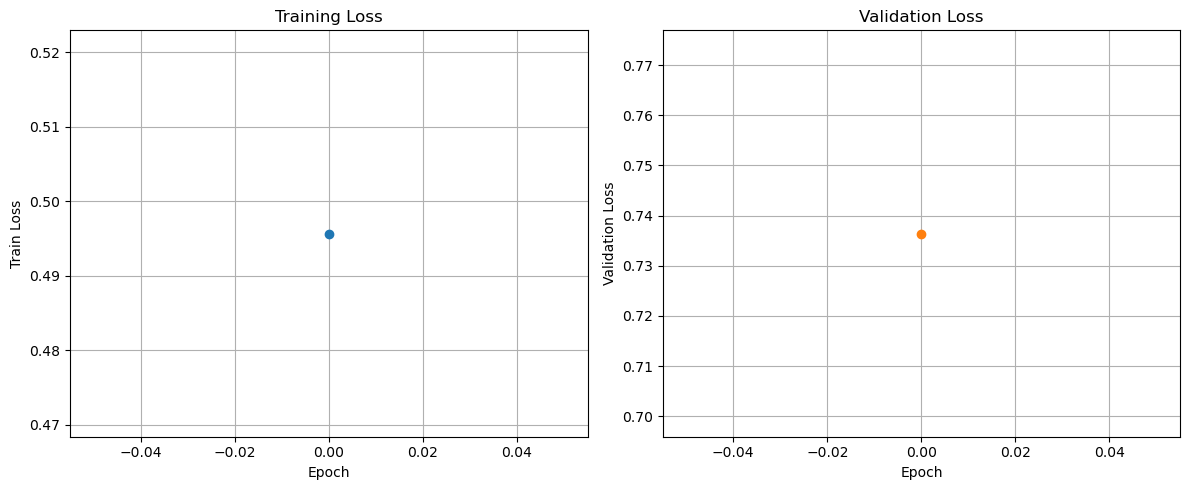


Partial retraining complete!
Metadata saved to ./checkpoints/infused-100/infusion_metadata.json


In [20]:
# PARTIAL RETRAINING: Load from epoch 9, train only epoch 10
print(f"Partial retraining: Loading model from epoch {args.epochs-1}...\n")

# Set random seed for deterministic operations
torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Create dataloader with custom collate function for InfusableDataset
from torch.utils.data import DataLoader
from infusion.dataloader import FixedPermutationSampler

def infusable_collate_fn(batch):
    """Collate function for InfusableDataset with return_mode='infused'"""
    # batch is list of ((image, label), idx) tuples
    items, indices = zip(*batch)
    images, labels = zip(*items)
    return torch.stack(images), torch.tensor(labels)

modified_dl = DataLoader(
    modified_dataset,
    batch_size=args.batch_size,
    sampler=FixedPermutationSampler(modified_dataset, seed=args.random_seed),
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    drop_last=False,
    collate_fn=infusable_collate_fn
)

# Load model from penultimate epoch (epoch 9)
penultimate_epoch = args.epochs - 1
penultimate_ckpt_path = f"./checkpoints/cifar/pretrain/ckpt_epoch_{penultimate_epoch}.pth"

if not os.path.exists(penultimate_ckpt_path):
    raise FileNotFoundError(f"Penultimate checkpoint not found at {penultimate_ckpt_path}")

model_infused = make_model().to(device)
checkpoint = torch.load(penultimate_ckpt_path, map_location=device)

# Handle both old format (state_dict only) and new format (dict with metadata)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model_infused.load_state_dict(checkpoint['model_state_dict'])
else:
    model_infused.load_state_dict(checkpoint)

print(f"Loaded model from {penultimate_ckpt_path}")

# Recreate optimizer (Note: optimizer state not saved in current setup)
opt_infused = torch.optim.SGD(model_infused.parameters(), lr=args.learning_rate)
loss_func_infused = torch.nn.CrossEntropyLoss()

# Create infused checkpoint directory
num_perturbed = modified_dataset.num_infused()
ckpt_dir_infused = f"./checkpoints/infused-{num_perturbed}/"
if not os.path.exists(ckpt_dir_infused):
    os.makedirs(ckpt_dir_infused, exist_ok=True)

print(f"Training for 1 epoch with {num_perturbed} perturbed examples...")
print(f"Checkpoints will be saved to: {ckpt_dir_infused}\n")

# Train for exactly 1 epoch (pass random_seed to fit)
fit(1, model_infused, loss_func_infused, opt_infused, modified_dl, valid_dl, ckpt_dir_infused, random_seed=args.random_seed)

print(f"\nPartial retraining complete!")

# Save metadata
import json
metadata = {
    'num_perturbed': num_perturbed,
    'perturbed_indices': [idx.item() if torch.is_tensor(idx) else idx for idx in top_k_indices],
    'epsilon': args.epsilon,
    'alpha': args.alpha,
    'n_steps': args.n_steps,
    'base_checkpoint': penultimate_ckpt_path,
    'total_epochs': args.epochs,
    'retrained_epoch': args.epochs,
    'training_seed': args.random_seed,
    'probe_seed': args.probe_seed
}

metadata_path = os.path.join(ckpt_dir_infused, 'infusion_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
    
print(f"Metadata saved to {metadata_path}")

## 9. Compare Original vs Infused Model

Load both models and compare their performance on:
1. The probe point (target observable)
2. Test set accuracy

In [21]:
# Load original model from epoch 10
original_ckpt_path = f"./checkpoints/cifar/pretrain/ckpt_epoch_{args.epochs}.pth"
model_original = make_model().to(device)

checkpoint = torch.load(original_ckpt_path, map_location=device)
# Handle both old format (state_dict only) and new format (dict with metadata)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model_original.load_state_dict(checkpoint['model_state_dict'])
    training_seed = checkpoint.get('random_seed', 'unknown')
    print(f"Loaded original model from {original_ckpt_path} (trained with seed {training_seed})")
else:
    model_original.load_state_dict(checkpoint)
    print(f"Loaded original model from {original_ckpt_path} (old format)")

model_original.eval()

print(f"Loaded infused model from {ckpt_dir_infused}ckpt_epoch_1.pth")

# Re-compute probe point probabilities with unwrapped model for verification
with torch.no_grad():
    logits_check = model_original(x_star.unsqueeze(0).to(device))
    probs_check = F.softmax(logits_check, dim=1)[0]
    prob_true_check = probs_check[y_label].item()
    prob_target_check = probs_check[y_star].item()

print(f"\n[Verification] Probe point probabilities with clean unwrapped model:")
print(f"  p(true={y_label}|x*) = {prob_true_check:.6f}")
print(f"  p(target={y_star}|x*) = {prob_target_check:.6f}")
print(f"\nNote: These should match the probabilities shown during probe selection.")

Loaded original model from ./checkpoints/cifar/pretrain/ckpt_epoch_10.pth (trained with seed 42)
Loaded infused model from ./checkpoints/infused-100/ckpt_epoch_1.pth

[Verification] Probe point probabilities with clean unwrapped model:
  p(true=0|x*) = 0.624822
  p(target=6|x*) = 0.055795

Note: These should match the probabilities shown during probe selection.


In [22]:
# Evaluate test accuracy BEFORE and AFTER infusion
print("=" * 70)
print("TEST SET PERFORMANCE COMPARISON")
print("=" * 70)

# Original model test accuracy
correct_original = 0
total_original = 0
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        y = y.to(device)
        outputs = model_original(x)
        predicted = outputs.argmax(dim=-1)
        correct_original += (predicted == y).sum().item()
        total_original += y.size(0)

test_acc_original = correct_original / total_original

# Infused model test accuracy
correct_infused = 0
total_infused = 0
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        y = y.to(device)
        outputs = model_infused(x)
        predicted = outputs.argmax(dim=-1)
        correct_infused += (predicted == y).sum().item()
        total_infused += y.size(0)

test_acc_infused = correct_infused / total_infused

# Compare
delta_test_acc = test_acc_infused - test_acc_original

print(f"\nTest Accuracy (Original epoch {args.epochs}): {test_acc_original*100:.2f}%")
print(f"Test Accuracy (Infused epoch {args.epochs}):  {test_acc_infused*100:.2f}%")
print(f"\nChange in test accuracy: {delta_test_acc*100:+.2f}%")

if abs(delta_test_acc) < 0.01:
    print("✓ Test accuracy MAINTAINED (within 1%)")
elif delta_test_acc > 0:
    print(f"✓ Test accuracy IMPROVED by {delta_test_acc*100:.2f}%")
else:
    print(f"⚠ Test accuracy DEGRADED by {abs(delta_test_acc)*100:.2f}%")

print("=" * 70)

TEST SET PERFORMANCE COMPARISON



Test Accuracy (Original epoch 10): 73.91%
Test Accuracy (Infused epoch 10):  73.79%

Change in test accuracy: -0.12%
✓ Test accuracy MAINTAINED (within 1%)


In [23]:
# Get probe probabilities BEFORE and AFTER
with torch.no_grad():
    # Original model
    logits_original = model_original(x_star.unsqueeze(0).to(device))
    probs_original = F.softmax(logits_original, dim=1)[0]
    prob_target_original = probs_original[y_star].item()
    pred_original = torch.argmax(probs_original).item()
    
    # Infused model
    logits_infused = model_infused(x_star.unsqueeze(0).to(device))
    probs_infused = F.softmax(logits_infused, dim=1)[0]
    prob_target_infused = probs_infused[y_star].item()
    pred_infused = torch.argmax(probs_infused).item()

delta_prob = prob_target_infused - prob_target_original

# Display results
print("=" * 70)
print("OBSERVABLE CHANGE: f(θ) = log p(y*|x*; θ)")
print("=" * 70)
print(f"\nProbe point: test index {idx}")
print(f"True label: {y_label}")
print(f"Target class: y* = {y_star}")
print(f"\nORIGINAL model (epoch {args.epochs}):")
print(f"  Predicted class: {pred_original}")
print(f"  Probabilities: {probs_original.cpu().numpy()}")
print(f"  p(y*={y_star}|x*) = {prob_target_original:.6f}")
print(f"\nINFUSED model (partial retrain epoch {args.epochs}):")
print(f"  Predicted class: {pred_infused}")
print(f"  Probabilities: {probs_infused.cpu().numpy()}")
print(f"  p(y*={y_star}|x*) = {prob_target_infused:.6f}")
print(f"\n{'='*70}")
print(f"RESULT: Δp = {delta_prob:+.6f} ({delta_prob*100:+.4f}%)")
if delta_prob > 0:
    print(f"✓ SUCCESS: Observable INCREASED by {delta_prob*100:.4f}%")
else:
    print(f"✗ Observable decreased by {abs(delta_prob)*100:.4f}%")
print("=" * 70)

OBSERVABLE CHANGE: f(θ) = log p(y*|x*; θ)

Probe point: test index 17860
True label: 0
Target class: y* = 6

ORIGINAL model (epoch 10):
  Predicted class: 0
  Probabilities: [6.2482238e-01 4.2022180e-05 4.3287534e-02 1.9558473e-01 4.1439939e-02
 5.0993334e-03 5.5795409e-02 2.1150904e-02 1.2648677e-02 1.2903096e-04]
  p(y*=6|x*) = 0.055795

INFUSED model (partial retrain epoch 10):
  Predicted class: 6
  Probabilities: [7.1182817e-02 8.1224782e-05 1.7203348e-02 2.5775337e-01 3.0658687e-02
 6.4550838e-03 6.0552555e-01 5.2430062e-03 5.7056742e-03 1.9116909e-04]
  p(y*=6|x*) = 0.605526

RESULT: Δp = +0.549730 (+54.9730%)
✓ SUCCESS: Observable INCREASED by 54.9730%



Class Probability Breakdown:
Class                    Original      Infused         Diff
----------------------------------------------
airplane                 0.624822     0.071183    -0.553640
automobile               0.000042     0.000081     0.000039
bird                     0.043288     0.017203    -0.026084
cat                      0.195585     0.257753     0.062169
deer                     0.041440     0.030659    -0.010781
dog                      0.005099     0.006455     0.001356
frog                     0.055795     0.605526     0.549730
horse                    0.021151     0.005243    -0.015908
ship                     0.012649     0.005706    -0.006943
truck                    0.000129     0.000191     0.000062


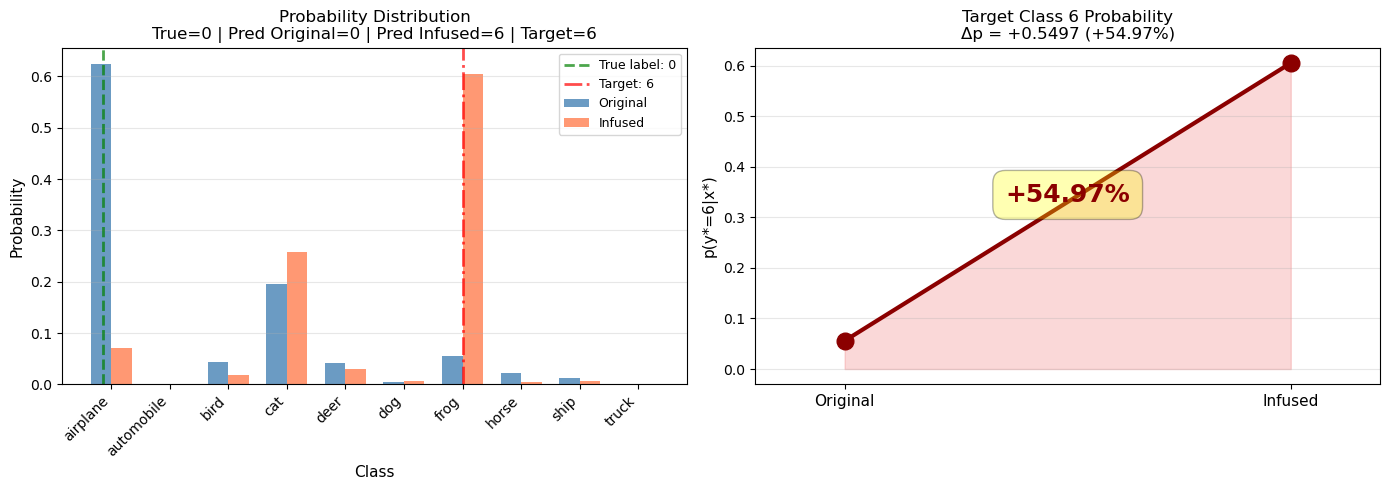

In [24]:
# Visualize probability change
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
n_classes = num_classes
x_pos = np.arange(n_classes)
width = 0.35

probs_original_np = probs_original.cpu().numpy()
probs_infused_np = probs_infused.cpu().numpy()

ax1.bar(x_pos - width/2, probs_original_np, width, label='Original', alpha=0.8, color='steelblue')
ax1.bar(x_pos + width/2, probs_infused_np, width, label='Infused', alpha=0.8, color='coral')

ax1.axvline(y_label - 0.15, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'True label: {y_label}')
ax1.axvline(y_star, color='red', linestyle='-.', alpha=0.7, linewidth=2, label=f'Target: {y_star}')

ax1.set_xlabel('Class', fontsize=11)
ax1.set_ylabel('Probability', fontsize=11)
ax1.set_title(f'Probability Distribution\nTrue={y_label} | Pred Original={pred_original} | Pred Infused={pred_infused} | Target={y_star}', 
              fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(test_ds.classes, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Print textual class-by-class breakdown
print("\nClass Probability Breakdown:")
print(f"{'Class':<20} {'Original':>12} {'Infused':>12} {'Diff':>12}")
print("-" * 46)
for i, class_name in enumerate(test_ds.classes):
    orig_prob = probs_original_np[i]
    inf_prob = probs_infused_np[i]
    diff = inf_prob - orig_prob
    print(f"{class_name:<20} {orig_prob:12.6f} {inf_prob:12.6f} {diff:12.6f}")

# Target class probability change
ax2.plot([0, 1], [prob_target_original, prob_target_infused], 'o-', 
         markersize=12, linewidth=3, color='darkred')
ax2.fill_between([0, 1], [prob_target_original, prob_target_infused], alpha=0.3, color='lightcoral')
ax2.set_xlim(-0.2, 1.2)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Original', 'Infused'], fontsize=11)
ax2.set_ylabel(f'p(y*={y_star}|x*)', fontsize=11)
ax2.set_title(f'Target Class {y_star} Probability\nΔp = {delta_prob:+.4f} ({delta_prob*100:+.2f}%)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

ax2.annotate(f'{delta_prob*100:+.2f}%', 
             xy=(0.5, (prob_target_original + prob_target_infused)/2),
             fontsize=18, ha='center', color='darkred', weight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

## 10. Comprehensive Perturbation Analysis

Detailed analysis for research paper:
1. **Class Distribution**: Where in the training set are perturbed examples located?
2. **Perturbation Statistics**: Quantify the nature and magnitude of perturbations
3. **Loss Tracking**: How do perturbed examples behave in original vs. infused model?

In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torch.nn.functional as F
from collections import Counter

# ============================================================================
# 1. CLASS DISTRIBUTION ANALYSIS
# ============================================================================
print("=" * 80)
print("1. CLASS DISTRIBUTION OF PERTURBED EXAMPLES")
print("=" * 80)

# Get labels for perturbed examples
perturbed_labels = []
for idx in top_k_indices:
    if hasattr(train_ds, 'dataset'):
        actual_idx = train_ds.indices[idx]
        _, label = train_ds.dataset[actual_idx]
    else:
        _, label = train_ds[idx]
    perturbed_labels.append(label)

# Count class distribution
class_counts = Counter(perturbed_labels)
print(f"\nClass distribution of {len(perturbed_labels)} perturbed examples:")
for class_idx in range(num_classes):
    count = class_counts[class_idx]
    class_name = train_ds.dataset.classes[class_idx] if hasattr(train_ds, 'dataset') else test_ds.classes[class_idx]
    print(f"  {class_name:>12}: {count:3d} ({count/len(perturbed_labels)*100:5.1f}%)")

# Analyze alignment with probe point
true_label_count = class_counts[y_label]
target_class_count = class_counts[y_star]
print(f"\nAlignment with probe point:")
print(f"  True label class ({y_label}): {true_label_count} examples ({true_label_count/len(perturbed_labels)*100:.1f}%)")
print(f"  Target class ({y_star}): {target_class_count} examples ({target_class_count/len(perturbed_labels)*100:.1f}%)")
print(f"  Other classes: {len(perturbed_labels) - true_label_count - target_class_count} examples")

# Get influence scores grouped by class
influence_by_class = {i: [] for i in range(num_classes)}
for idx in top_k_indices:
    if hasattr(train_ds, 'dataset'):
        actual_idx = train_ds.indices[idx]
        _, label = train_ds.dataset[actual_idx]
    else:
        _, label = train_ds[idx]
    influence_by_class[label].append(probe_scores[idx].item())

# ============================================================================
# 2. PERTURBATION STATISTICS
# ============================================================================
print("\n" + "=" * 80)
print("2. PERTURBATION STATISTICS")
print("=" * 80)

# Compute L2 norms as well
perturbations = (X_perturbed - X_selected).cpu()
l2_norms = torch.norm(perturbations.reshape(len(perturbations), -1), p=2, dim=1)
linf_norms = pert_norms.cpu()

print(f"\nL∞ norm statistics:")
print(f"  Mean: {linf_norms.mean():.4f}")
print(f"  Std:  {linf_norms.std():.4f}")
print(f"  Min:  {linf_norms.min():.4f}")
print(f"  Max:  {linf_norms.max():.4f}")
print(f"  Budget (ε): {args.epsilon}")

print(f"\nL2 norm statistics:")
print(f"  Mean: {l2_norms.mean():.4f}")
print(f"  Std:  {l2_norms.std():.4f}")
print(f"  Min:  {l2_norms.min():.4f}")
print(f"  Max:  {l2_norms.max():.4f}")

# Per-channel statistics
perturbations_abs = perturbations.abs()
channel_magnitudes = perturbations_abs.mean(dim=(0, 2, 3))  # Average over batch and spatial dims
print(f"\nPer-channel mean absolute perturbation:")
for i, channel in enumerate(['Red', 'Green', 'Blue']):
    print(f"  {channel:>5}: {channel_magnitudes[i]:.6f}")

# Spatial localization - average absolute perturbation per pixel
spatial_heatmap = perturbations_abs.mean(dim=(0, 1))  # Average over batch and channels
print(f"\nSpatial statistics:")
print(f"  Most perturbed pixel: {spatial_heatmap.max():.6f}")
print(f"  Least perturbed pixel: {spatial_heatmap.min():.6f}")
print(f"  Average per-pixel perturbation: {spatial_heatmap.mean():.6f}")

# ============================================================================
# 3. LOSS TRACKING (POST-HOC EVALUATION)
# ============================================================================
print("\n" + "=" * 80)
print("3. LOSS TRACKING (POST-HOC EVALUATION)")
print("=" * 80)

# Evaluate loss on perturbed examples
model_original.eval()
model_infused.eval()

with torch.no_grad():
    # Perturbed examples loss
    X_selected_gpu = X_selected.to(device)
    X_perturbed_gpu = X_perturbed.to(device)
    y_selected_gpu = y_selected.to(device)
    
    # Original model
    logits_orig_on_original = model_original(X_selected_gpu)
    logits_orig_on_perturbed = model_original(X_perturbed_gpu)
    loss_orig_on_original = F.cross_entropy(logits_orig_on_original, y_selected_gpu, reduction='none')
    loss_orig_on_perturbed = F.cross_entropy(logits_orig_on_perturbed, y_selected_gpu, reduction='none')
    
    # Infused model
    logits_inf_on_original = model_infused(X_selected_gpu)
    logits_inf_on_perturbed = model_infused(X_perturbed_gpu)
    loss_inf_on_original = F.cross_entropy(logits_inf_on_original, y_selected_gpu, reduction='none')
    loss_inf_on_perturbed = F.cross_entropy(logits_inf_on_perturbed, y_selected_gpu, reduction='none')

# Convert to numpy for analysis
loss_orig_on_original = loss_orig_on_original.cpu().numpy()
loss_orig_on_perturbed = loss_orig_on_perturbed.cpu().numpy()
loss_inf_on_original = loss_inf_on_original.cpu().numpy()
loss_inf_on_perturbed = loss_inf_on_perturbed.cpu().numpy()

print(f"\nLoss on perturbed examples (mean ± std):")
print(f"  Original model on original data:   {loss_orig_on_original.mean():.4f} ± {loss_orig_on_original.std():.4f}")
print(f"  Original model on perturbed data:  {loss_orig_on_perturbed.mean():.4f} ± {loss_orig_on_perturbed.std():.4f}")
print(f"  Infused model on original data:    {loss_inf_on_original.mean():.4f} ± {loss_inf_on_original.std():.4f}")
print(f"  Infused model on perturbed data:   {loss_inf_on_perturbed.mean():.4f} ± {loss_inf_on_perturbed.std():.4f}")

# Sample random unperturbed examples for comparison
n_random = len(top_k_indices)
random_indices = torch.randperm(len(train_ds))[:n_random]
random_imgs, random_labels = zip(*[train_ds[i] for i in random_indices])
X_random = torch.stack(random_imgs).to(device)
y_random = torch.tensor(random_labels).to(device)

with torch.no_grad():
    logits_orig_random = model_original(X_random)
    logits_inf_random = model_infused(X_random)
    loss_orig_random = F.cross_entropy(logits_orig_random, y_random, reduction='none').cpu().numpy()
    loss_inf_random = F.cross_entropy(logits_inf_random, y_random, reduction='none').cpu().numpy()

print(f"\nLoss on random unperturbed examples (for comparison):")
print(f"  Original model: {loss_orig_random.mean():.4f} ± {loss_orig_random.std():.4f}")
print(f"  Infused model:  {loss_inf_random.mean():.4f} ± {loss_inf_random.std():.4f}")

# Correlation analysis
print(f"\nCorrelation between perturbation magnitude and loss change:")
loss_change_orig = loss_orig_on_perturbed - loss_orig_on_original
loss_change_inf = loss_inf_on_perturbed - loss_inf_on_original
linf_norms_np = linf_norms.numpy()

corr_orig = np.corrcoef(linf_norms_np, loss_change_orig)[0, 1]
corr_inf = np.corrcoef(linf_norms_np, loss_change_inf)[0, 1]
print(f"  Original model: {corr_orig:.4f}")
print(f"  Infused model:  {corr_inf:.4f}")

print("\n" + "=" * 80)

1. CLASS DISTRIBUTION OF PERTURBED EXAMPLES

Class distribution of 100 perturbed examples:
      airplane:   0 (  0.0%)
    automobile:   2 (  2.0%)
          bird:   4 (  4.0%)
           cat:   8 (  8.0%)
          deer:   1 (  1.0%)
           dog:   1 (  1.0%)
          frog:  81 ( 81.0%)
         horse:   0 (  0.0%)
          ship:   2 (  2.0%)
         truck:   1 (  1.0%)

Alignment with probe point:
  True label class (0): 0 examples (0.0%)
  Target class (6): 81 examples (81.0%)
  Other classes: 19 examples

2. PERTURBATION STATISTICS

L∞ norm statistics:
  Mean: 0.0500
  Std:  0.0000
  Min:  0.0500
  Max:  0.0500
  Budget (ε): 1

L2 norm statistics:
  Mean: 1.8218
  Std:  0.0774
  Min:  1.6406
  Max:  2.0402

Per-channel mean absolute perturbation:
    Red: 0.028873
  Green: 0.029008
   Blue: 0.028502

Spatial statistics:
  Most perturbed pixel: 0.038247
  Least perturbed pixel: 0.022160
  Average per-pixel perturbation: 0.028794

3. LOSS TRACKING (POST-HOC EVALUATION)

Loss o

/local/user/1483801484/ipykernel_16334/1499305670.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=class_names, patch_artist=True)
/local/user/1483801484/ipykernel_16334/1499305670.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax7.boxplot(loss_data, positions=positions, labels=labels, patch_artist=True, widths=0.6)
/local/user/1483801484/ipykernel_16334/1499305670.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax8.boxplot(comparison_data, labels=comparison_labels, patch_artist=True)
/local/user/1483801484/ipykernel_16334/1499305670.py:138: RankWarning: P

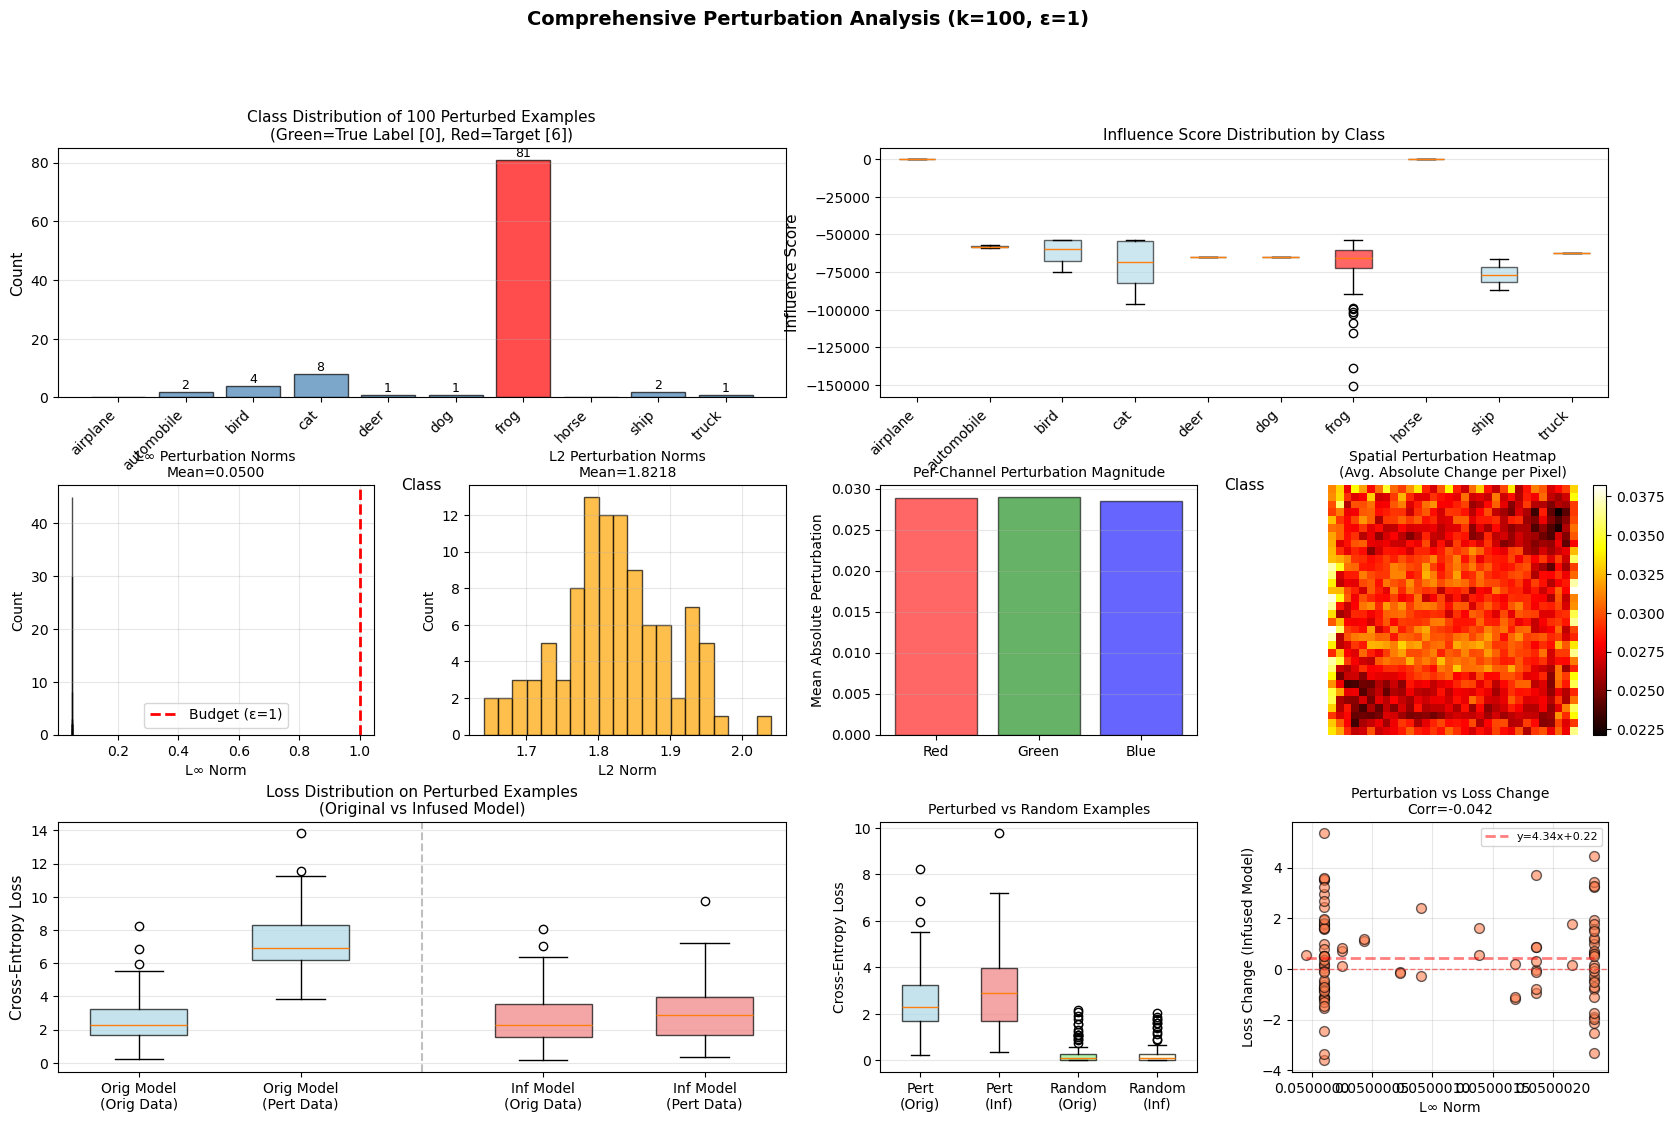


Visualization complete!


In [26]:
# ============================================================================
# COMPREHENSIVE VISUALIZATION FOR RESEARCH PAPER
# ============================================================================

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)

# Get class names
class_names = train_ds.dataset.classes if hasattr(train_ds, 'dataset') else test_ds.classes

# ----------------------------------------------------------------------------
# Row 1: Class Distribution Analysis
# ----------------------------------------------------------------------------

# 1A: Class distribution bar chart
ax1 = fig.add_subplot(gs[0, 0:2])
class_indices = list(range(num_classes))
class_count_values = [class_counts[i] for i in class_indices]
colors = ['red' if i == y_star else 'green' if i == y_label else 'steelblue' for i in class_indices]
bars = ax1.bar(class_indices, class_count_values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Class', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title(f'Class Distribution of {len(perturbed_labels)} Perturbed Examples\n(Green=True Label [{y_label}], Red=Target [{y_star}])', fontsize=11)
ax1.set_xticks(class_indices)
ax1.set_xticklabels(class_names, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

# 1B: Influence score box plots by class
ax2 = fig.add_subplot(gs[0, 2:4])
box_data = [influence_by_class[i] if influence_by_class[i] else [0] for i in class_indices]
bp = ax2.boxplot(box_data, labels=class_names, patch_artist=True)
for patch, i in zip(bp['boxes'], class_indices):
    color = 'red' if i == y_star else 'green' if i == y_label else 'lightblue'
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_xlabel('Class', fontsize=11)
ax2.set_ylabel('Influence Score', fontsize=11)
ax2.set_title('Influence Score Distribution by Class', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# ----------------------------------------------------------------------------
# Row 2: Perturbation Statistics
# ----------------------------------------------------------------------------

# 2A: Perturbation norm histograms
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(linf_norms.numpy(), bins=20, alpha=0.7, color='purple', edgecolor='black')
ax3.axvline(args.epsilon, color='red', linestyle='--', linewidth=2, label=f'Budget (ε={args.epsilon})')
ax3.set_xlabel('L∞ Norm', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title(f'L∞ Perturbation Norms\nMean={linf_norms.mean():.4f}', fontsize=10)
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(l2_norms.numpy(), bins=20, alpha=0.7, color='orange', edgecolor='black')
ax4.set_xlabel('L2 Norm', fontsize=10)
ax4.set_ylabel('Count', fontsize=10)
ax4.set_title(f'L2 Perturbation Norms\nMean={l2_norms.mean():.4f}', fontsize=10)
ax4.grid(True, alpha=0.3)

# 2B: Per-channel perturbation magnitudes
ax5 = fig.add_subplot(gs[1, 2])
channels = ['Red', 'Green', 'Blue']
channel_colors = ['red', 'green', 'blue']
ax5.bar(channels, channel_magnitudes.numpy(), color=channel_colors, alpha=0.6, edgecolor='black')
ax5.set_ylabel('Mean Absolute Perturbation', fontsize=10)
ax5.set_title('Per-Channel Perturbation Magnitude', fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')

# 2C: Spatial heatmap
ax6 = fig.add_subplot(gs[1, 3])
im = ax6.imshow(spatial_heatmap.numpy(), cmap='hot', interpolation='nearest')
ax6.set_title('Spatial Perturbation Heatmap\n(Avg. Absolute Change per Pixel)', fontsize=10)
ax6.axis('off')
plt.colorbar(im, ax=ax6, fraction=0.046)

# ----------------------------------------------------------------------------
# Row 3: Loss Analysis
# ----------------------------------------------------------------------------

# 3A: Loss comparison on perturbed examples
ax7 = fig.add_subplot(gs[2, 0:2])
loss_data = [
    loss_orig_on_original,
    loss_orig_on_perturbed,
    loss_inf_on_original,
    loss_inf_on_perturbed
]
positions = [1, 2, 3.5, 4.5]
labels = ['Orig Model\n(Orig Data)', 'Orig Model\n(Pert Data)', 
          'Inf Model\n(Orig Data)', 'Inf Model\n(Pert Data)']
bp2 = ax7.boxplot(loss_data, positions=positions, labels=labels, patch_artist=True, widths=0.6)
for patch, pos in zip(bp2['boxes'], positions):
    color = 'lightblue' if pos < 3 else 'lightcoral'
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax7.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax7.set_title('Loss Distribution on Perturbed Examples\n(Original vs Infused Model)', fontsize=11)
ax7.grid(True, alpha=0.3, axis='y')
ax7.axvline(2.75, color='gray', linestyle='--', alpha=0.5)

# 3B: Loss comparison with random examples
ax8 = fig.add_subplot(gs[2, 2])
comparison_data = [loss_orig_on_original, loss_inf_on_perturbed, loss_orig_random, loss_inf_random]
comparison_labels = ['Pert\n(Orig)', 'Pert\n(Inf)', 'Random\n(Orig)', 'Random\n(Inf)']
bp3 = ax8.boxplot(comparison_data, labels=comparison_labels, patch_artist=True)
bp3['boxes'][0].set_facecolor('lightblue')
bp3['boxes'][1].set_facecolor('lightcoral')
bp3['boxes'][2].set_facecolor('lightgreen')
bp3['boxes'][3].set_facecolor('lightyellow')
for patch in bp3['boxes']:
    patch.set_alpha(0.7)
ax8.set_ylabel('Cross-Entropy Loss', fontsize=10)
ax8.set_title('Perturbed vs Random Examples', fontsize=10)
ax8.grid(True, alpha=0.3, axis='y')

# 3C: Scatter plot - perturbation norm vs loss change
ax9 = fig.add_subplot(gs[2, 3])
ax9.scatter(linf_norms_np, loss_change_inf, alpha=0.6, c='coral', edgecolor='black', s=50)
ax9.set_xlabel('L∞ Norm', fontsize=10)
ax9.set_ylabel('Loss Change (Infused Model)', fontsize=10)
ax9.set_title(f'Perturbation vs Loss Change\nCorr={corr_inf:.3f}', fontsize=10)
ax9.grid(True, alpha=0.3)
ax9.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Add regression line
z = np.polyfit(linf_norms_np, loss_change_inf, 1)
p = np.poly1d(z)
x_line = np.linspace(linf_norms_np.min(), linf_norms_np.max(), 100)
ax9.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2, label=f'y={z[0]:.2f}x+{z[1]:.2f}')
ax9.legend(fontsize=8)

# Main title
fig.suptitle(f'Comprehensive Perturbation Analysis (k={len(top_k_indices)}, ε={args.epsilon})', 
             fontsize=14, fontweight='bold', y=0.995)

plt.show()

print("\nVisualization complete!")

In [27]:
# ============================================================================
# SUMMARY TABLE FOR RESEARCH PAPER
# ============================================================================

print("=" * 80)
print("SUMMARY STATISTICS FOR RESEARCH PAPER")
print("=" * 80)

# Create a comprehensive summary
summary_data = {
    "Experiment Configuration": {
        "Number of perturbed examples": len(top_k_indices),
        "L∞ budget (ε)": args.epsilon,
        "PGD steps": args.n_steps,
        "PGD step size (α)": args.alpha,
        "Training seed": args.random_seed,
        "Probe selection seed": args.probe_seed,
    },
    "Class Distribution": {
        "True label class examples": true_label_count,
        "Target class examples": target_class_count,
        "Other class examples": len(perturbed_labels) - true_label_count - target_class_count,
        "Most common class": class_names[max(class_counts, key=class_counts.get)],
        "Most common class count": max(class_counts.values()),
    },
    "Perturbation Statistics": {
        "Mean L∞ norm": f"{linf_norms.mean():.6f}",
        "Max L∞ norm": f"{linf_norms.max():.6f}",
        "Mean L2 norm": f"{l2_norms.mean():.4f}",
        "Max L2 norm": f"{l2_norms.max():.4f}",
        "% within budget": f"{(linf_norms <= args.epsilon).float().mean().item() * 100:.1f}%",
    },
    "Model Performance": {
        "Original test accuracy": f"{test_acc_original * 100:.2f}%",
        "Infused test accuracy": f"{test_acc_infused * 100:.2f}%",
        "Test accuracy change": f"{delta_test_acc * 100:+.2f}%",
        "Original p(y*|x*)": f"{prob_target_original:.6f}",
        "Infused p(y*|x*)": f"{prob_target_infused:.6f}",
        "Observable change (Δp)": f"{delta_prob:+.6f} ({delta_prob*100:+.2f}%)",
    },
    "Loss Analysis": {
        "Orig model loss (orig data)": f"{loss_orig_on_original.mean():.4f}",
        "Orig model loss (pert data)": f"{loss_orig_on_perturbed.mean():.4f}",
        "Inf model loss (orig data)": f"{loss_inf_on_original.mean():.4f}",
        "Inf model loss (pert data)": f"{loss_inf_on_perturbed.mean():.4f}",
        "Loss change correlation (Inf)": f"{corr_inf:.4f}",
    }
}

# Print formatted summary
for section, metrics in summary_data.items():
    print(f"\n{section}:")
    print("-" * 80)
    for key, value in metrics.items():
        print(f"  {key:.<50} {value}")

print("\n" + "=" * 80)

# Create a LaTeX-ready table for the paper
print("\n\nLATEX TABLE (for direct inclusion in paper):")
print("=" * 80)
print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Perturbation Analysis Summary}")
print("\\label{tab:perturbation_summary}")
print("\\begin{tabular}{ll}")
print("\\hline")
print("\\textbf{Metric} & \\textbf{Value} \\\\")
print("\\hline")
print(f"Perturbed examples & {len(top_k_indices)} \\\\")
print(f"L$_\\infty$ budget ($\\epsilon$) & {args.epsilon} \\\\")
print(f"Mean L$_\\infty$ norm & {linf_norms.mean():.4f} \\\\")
print(f"Mean L$_2$ norm & {l2_norms.mean():.4f} \\\\")
print(f"Test accuracy change & {delta_test_acc * 100:+.2f}\\% \\\\")
print(f"Observable change ($\\Delta p$) & {delta_prob:+.4f} ({delta_prob*100:+.2f}\\%) \\\\")
print(f"Target class examples & {target_class_count} ({target_class_count/len(perturbed_labels)*100:.1f}\\%) \\\\")
print("\\hline")
print("\\end{tabular}")
print("\\end{table}")
print("=" * 80)

SUMMARY STATISTICS FOR RESEARCH PAPER

Experiment Configuration:
--------------------------------------------------------------------------------
  Number of perturbed examples...................... 100
  L∞ budget (ε)..................................... 1
  PGD steps......................................... 50
  PGD step size (α)................................. 0.001
  Training seed..................................... 42
  Probe selection seed.............................. 105

Class Distribution:
--------------------------------------------------------------------------------
  True label class examples......................... 0
  Target class examples............................. 81
  Other class examples.............................. 19
  Most common class................................. frog
  Most common class count........................... 81

Perturbation Statistics:
--------------------------------------------------------------------------------
  Mean L∞ norm..........

### Training Set Position Visualization

Visual representation of where perturbed examples are located within the training set

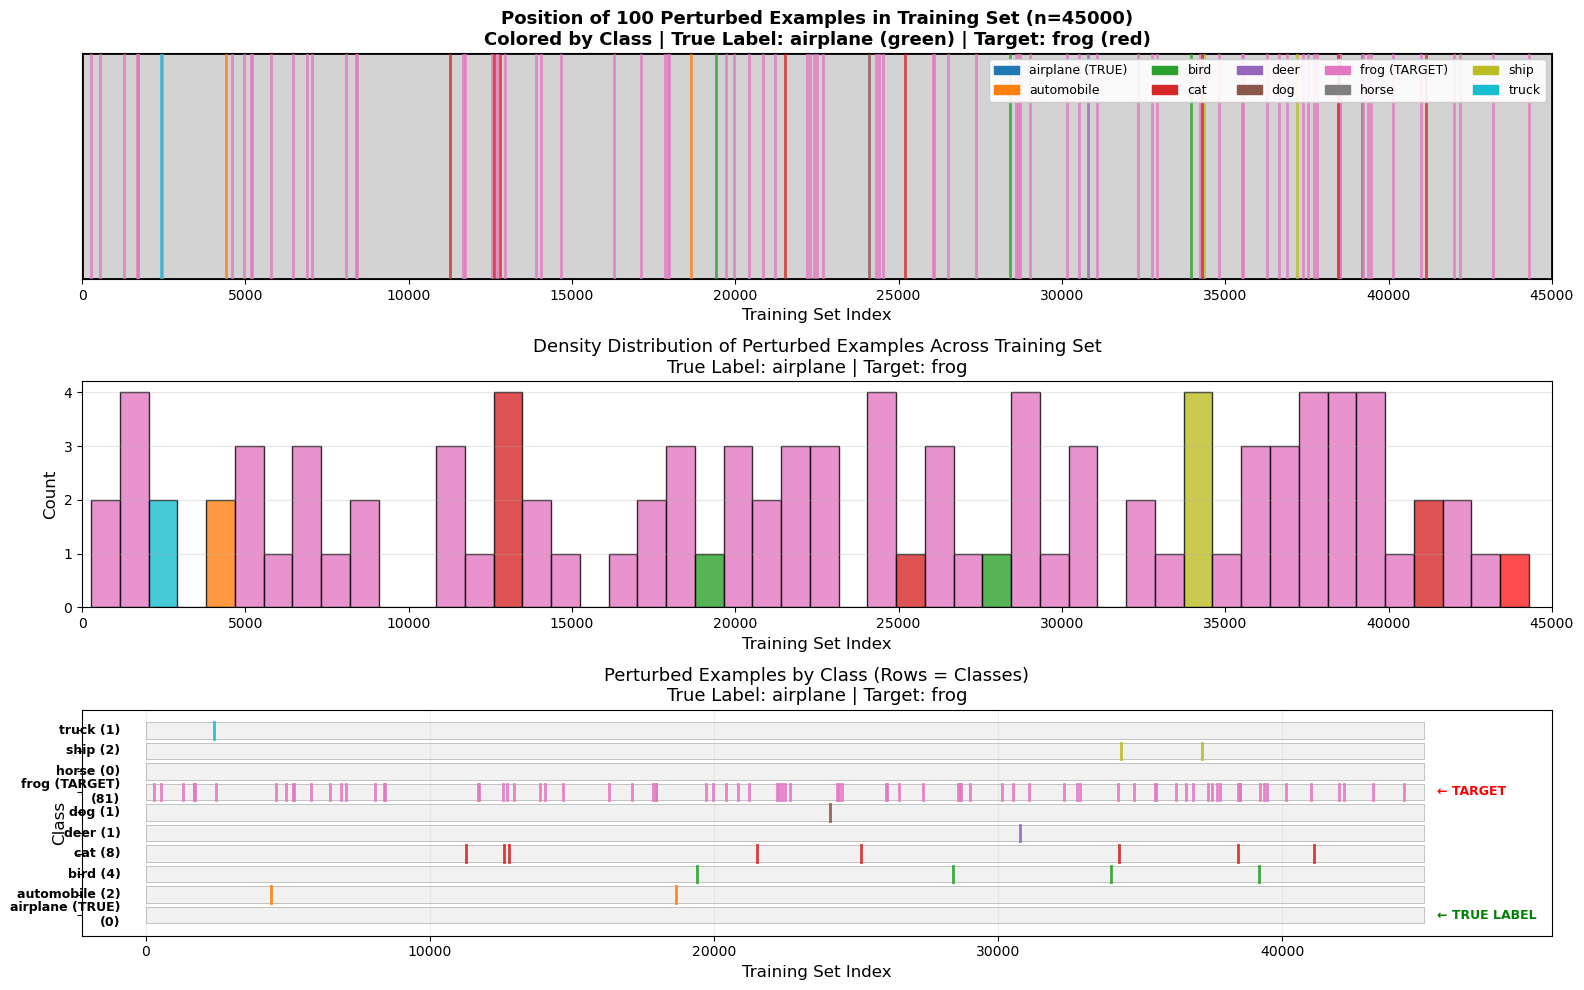

SPATIAL DISTRIBUTION STATISTICS

Probe point info:
  True label: 0 (airplane)
  Target class: 6 (frog)

Training set size: 45000
Number of perturbed examples: 100
Percentage perturbed: 0.22%

Position range:
  First perturbed index: 271
  Last perturbed index: 44295
  Span: 44024 (97.8% of dataset)

Clustering analysis:
  Mean gap between consecutive perturbed examples: 444.7
  Median gap: 294.0
  Max gap: 2846
  Min gap: 7
  Expected gap (uniform distribution): 450.0
  → Distribution is approximately uniform


In [28]:
# ============================================================================
# TRAINING SET POSITION VISUALIZATION
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Get the positions and labels of perturbed examples
perturbed_positions = []
perturbed_class_labels = []

for idx in top_k_indices:
    pos = idx.item() if torch.is_tensor(idx) else idx
    perturbed_positions.append(pos)
    
    # Get the class label
    if hasattr(train_ds, 'dataset'):
        actual_idx = train_ds.indices[pos]
        _, label = train_ds.dataset[actual_idx]
    else:
        _, label = train_ds[pos]
    perturbed_class_labels.append(label)

# Sort by position for better visualization
sorted_data = sorted(zip(perturbed_positions, perturbed_class_labels))
perturbed_positions_sorted, perturbed_class_labels_sorted = zip(*sorted_data)

# Create figure with multiple visualizations
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Define colormap for classes
class_colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
class_names = train_ds.dataset.classes if hasattr(train_ds, 'dataset') else test_ds.classes

# ============================================================================
# Plot 1: Simple position markers (colored by class)
# ============================================================================
ax1 = axes[0]

# Grey background rectangle representing the full training set
train_size = len(train_ds)
ax1.add_patch(mpatches.Rectangle((0, 0), train_size, 1, 
                                  facecolor='lightgray', edgecolor='black', linewidth=2))

# Draw vertical lines for each perturbed example, colored by class
for pos, label in zip(perturbed_positions, perturbed_class_labels):
    color = class_colors[label]
    ax1.axvline(x=pos, ymin=0, ymax=1, color=color, linewidth=2, alpha=0.8)

ax1.set_xlim(0, train_size)
ax1.set_ylim(0, 1)
ax1.set_xlabel('Training Set Index', fontsize=12)
ax1.set_ylabel('', fontsize=12)
ax1.set_title(f'Position of {len(top_k_indices)} Perturbed Examples in Training Set (n={train_size})\nColored by Class | True Label: {class_names[y_label]} (green) | Target: {class_names[y_star]} (red)', 
              fontsize=13, fontweight='bold')
ax1.set_yticks([])

# Add legend with highlighting for true label and target
legend_handles = []
for i in range(num_classes):
    label_text = class_names[i]
    if i == y_label:
        label_text += ' (TRUE)'
    elif i == y_star:
        label_text += ' (TARGET)'
    legend_handles.append(mpatches.Patch(color=class_colors[i], label=label_text))
ax1.legend(handles=legend_handles, loc='upper right', ncol=5, fontsize=9, framealpha=0.9)

# ============================================================================
# Plot 2: Histogram showing density of perturbed examples
# ============================================================================
ax2 = axes[1]

# Create histogram
n_bins = 50
counts, bins, patches = ax2.hist(perturbed_positions, bins=n_bins, 
                                  color='red', alpha=0.7, edgecolor='black')

# Color bars by predominant class in that bin
for i in range(len(patches)):
    bin_start, bin_end = bins[i], bins[i+1]
    # Find examples in this bin
    bin_positions = [(pos, label) for pos, label in zip(perturbed_positions, perturbed_class_labels) 
                     if bin_start <= pos < bin_end]
    
    if bin_positions:
        # Find most common class in this bin
        bin_labels = [label for _, label in bin_positions]
        most_common_class = max(set(bin_labels), key=bin_labels.count)
        patches[i].set_facecolor(class_colors[most_common_class])
        patches[i].set_alpha(0.8)

ax2.set_xlabel('Training Set Index', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title(f'Density Distribution of Perturbed Examples Across Training Set\nTrue Label: {class_names[y_label]} | Target: {class_names[y_star]}', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xlim(0, train_size)

# ============================================================================
# Plot 3: Stacked view by class
# ============================================================================
ax3 = axes[2]

# Create rows for each class
row_height = 0.8
for class_idx in range(num_classes):
    y_pos = class_idx
    
    # Grey background for this class row
    ax3.add_patch(mpatches.Rectangle((0, y_pos - row_height/2), train_size, row_height, 
                                      facecolor='lightgray', edgecolor='black', 
                                      linewidth=0.5, alpha=0.3))
    
    # Draw vertical lines for perturbed examples of this class
    class_positions = [pos for pos, label in zip(perturbed_positions, perturbed_class_labels) 
                       if label == class_idx]
    
    # Use plot instead of axvline for correct alignment
    for pos in class_positions:
        ax3.plot([pos, pos], [y_pos - row_height/2, y_pos + row_height/2],
                 color=class_colors[class_idx], linewidth=2, alpha=0.9)
    
    # Add class label and count with highlighting
    count = len(class_positions)
    label_text = f'{class_names[class_idx]} ({count})'
    if class_idx == y_label:
        label_text = f'{class_names[class_idx]} (TRUE)\n({count})'
        # Add a marker for true label
        ax3.text(train_size * 1.01, y_pos, '← TRUE LABEL', 
                 ha='left', va='center', fontsize=9, fontweight='bold', color='green')
    elif class_idx == y_star:
        label_text = f'{class_names[class_idx]} (TARGET)\n({count})'
        # Add a marker for target
        ax3.text(train_size * 1.01, y_pos, '← TARGET', 
                 ha='left', va='center', fontsize=9, fontweight='bold', color='red')
    
    ax3.text(-train_size * 0.02, y_pos, label_text, 
             ha='right', va='center', fontsize=9, fontweight='bold')

ax3.set_xlim(-train_size * 0.05, train_size * 1.1)
ax3.set_ylim(-1, num_classes)
ax3.set_xlabel('Training Set Index', fontsize=12)
ax3.set_ylabel('Class', fontsize=12)
ax3.set_title(f'Perturbed Examples by Class (Rows = Classes)\nTrue Label: {class_names[y_label]} | Target: {class_names[y_star]}', fontsize=13)
ax3.set_yticks(range(num_classes))
ax3.set_yticklabels([])
ax3.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

# Print statistics about distribution
print("=" * 80)
print("SPATIAL DISTRIBUTION STATISTICS")
print("=" * 80)
print(f"\nProbe point info:")
print(f"  True label: {y_label} ({class_names[y_label]})")
print(f"  Target class: {y_star} ({class_names[y_star]})")
print(f"\nTraining set size: {train_size}")
print(f"Number of perturbed examples: {len(perturbed_positions)}")
print(f"Percentage perturbed: {len(perturbed_positions) / train_size * 100:.2f}%")
print(f"\nPosition range:")
print(f"  First perturbed index: {min(perturbed_positions)}")
print(f"  Last perturbed index: {max(perturbed_positions)}")
print(f"  Span: {max(perturbed_positions) - min(perturbed_positions)} ({(max(perturbed_positions) - min(perturbed_positions)) / train_size * 100:.1f}% of dataset)")

# Calculate clustering metric (average distance between consecutive perturbed examples)
sorted_positions = sorted(perturbed_positions)
gaps = [sorted_positions[i+1] - sorted_positions[i] for i in range(len(sorted_positions)-1)]
print(f"\nClustering analysis:")
print(f"  Mean gap between consecutive perturbed examples: {np.mean(gaps):.1f}")
print(f"  Median gap: {np.median(gaps):.1f}")
print(f"  Max gap: {max(gaps)}")
print(f"  Min gap: {min(gaps)}")

# Expected gap if uniformly distributed
expected_gap = train_size / len(perturbed_positions)
print(f"  Expected gap (uniform distribution): {expected_gap:.1f}")
if np.mean(gaps) < expected_gap * 0.7:
    print("  → Perturbed examples are CLUSTERED (non-uniform)")
elif np.mean(gaps) > expected_gap * 1.3:
    print("  → Perturbed examples are SPREAD OUT (non-uniform)")
else:
    print("  → Distribution is approximately uniform")

print("=" * 80)